In [94]:
# -*- coding: utf-8 -*-
"""
Created on Thu Jan  2 15:50:57 2025

@author: Pau
"""
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Latex

Distretization

In [95]:
T = 300 #days
n = 7200 #2400 hours in 100 days
dt = T/n #T/n
t = np.zeros(n+1)

Input

In [105]:
C_air_cs = np.zeros(n+1)
C_air_i = np.zeros(n+1)

C_air_cs[:12] = [3.2*10**2, 3.2*10**3, 3.2*10**4, 3.2*10**4, 3.2*10**4, 3.2*10**4, 3.2*10**4, 3.2*10**4, 3.2*10**4, 3.2*10**3, 3.2*10**2, 0] # Concentration in the air (Bq/m^3)
C_air_i[:12] = [3.2*10**2, 3.2*10**3, 3.2*10**4, 3.2*10**4, 3.2*10**4, 3.2*10**4, 3.2*10**4, 3.2*10**4, 3.2*10**4, 3.2*10**3, 3.2*10**2, 0] # Concentration in the air (Bq/m^3)

Parameters

In [106]:
#---------------- Field type repartition ------------#

a = 0.70 #ordinary field
b = 0.10 #rice
c = 0.20 #pasture

#------------------- TO COMPUTE kre------------------#

RF_agri = 10**(-5) #=RFv_
RF_rice = 0 
RF_pasture = np.zeros(n+1) 
kre = np.zeros(n+1) #averaged over the 3 types of field

#----------------TO COMPUTE Bf & kup------------------#

CR = 0.04 #FOR CESIUM
CR_i = 0.02 #FOR IODINE
ro_r = (a+c) * 1180 + b * 1040
L_r = a * 0.25 + b*0.25 + c*0.15 # roots of the plants
k_g = 0.12
B_max = a*2+b*1.32+c*0.49 # maximum potential biomass = above the ground
B_0 = (a+b)*0.015+c*0.07 # given initial biomass
Bf = np.zeros(n+1)
derivative_Bf = np.zeros(n+1)
kup = np.zeros(n+1)

#-------------------TO COMPUTE kl---------------------#

f_c = 10**3 #L/m^3
f_p = a*1+b*0.8+c*1 #paper page 4
Precipitation= 0.00005 #m/d
Irrigation = a*0.0036 + b*0.0049 + c*0.0022 #m/d
Evaporation = 0.0032 #m/d
R_p = f_p*Precipitation+Irrigation-Evaporation
teta= (a+c)*270+b*600
M_d=1000 #FOR CESIUM
M_d_i = 90 #FOR IODINE
kl =f_c*R_p/(teta*L_r*(1+ro_r*M_d/teta))
kl_i = f_c*R_p/(teta*L_r*(1+ro_r*M_d_i/teta))

#-------------------Other parameters------------------#


kw = 2.77E-02
kpc = 1.98E-02
ktr = 5.5E-03 #FOR CESIUM
ktr_i = 8.5E-03 #FOR IODINE
kad = 1.9E-03 # For Cs but no value for I
kds = 2.1E-04 # For Cs but no value for I
lambda_g = 3.47E-02
lambda_d = np.log(2)/(30.1*365) #Cs
alpha= a*0.3 + (b+c)*3
Be = a*0.2 + b*0.44 + c*0.49 
f=np.zeros(n+1)
vd_cs = 0.0007 * 3600 * 24 # FOR CESIUM
vd_i = 0.0045 * 3600 * 24 #FOR IODINE

CONCENTRATIONS FOR CESIUM

In [107]:
#Initial conditions
X1_cs = np.zeros(n+1) #Concentration at the plant surface (Bq/dry-kg)
X2_cs = np.zeros(n+1) #Concentration in inner tissues (Bq/dry-kg)
X3_cs = np.zeros(n+1) #Concentration at the surface soil (Bq/dry-m²)
X4_cs = np.zeros(n+1) #Concentration in the root zone (Bq/dry-m²)
X5_cs = np.zeros(n+1) #Concentration in the fix soil (Bq/dry-m²)
X6_cs = np.zeros(n+1) #Concentration in the deep soil (Bq/dry-m²)

X1_cs[0] = 0 
X2_cs[0] = 0
X3_cs[0] = 0 
X4_cs[0] = 0
X5_cs[0] = 0
X6_cs[0] = 0

#Euler method
for i in range(n):
    RF_pasture[i] = 10**(-6) * np.exp(-0.01*i*dt) + 10**(-9)
    kre[i] = vd_cs * (a*RF_agri + b*RF_rice + c*RF_pasture[i])

    Bf[i] = B_max * B_0 / ((B_max - B_0)*np.exp(-k_g*i*dt)+ B_0)
    derivative_Bf[i]=(B_max*B_0)*1/((B_max-B_0)*np.exp(-k_g*i*dt)+B_0)**2**(B_max-B_0)*k_g*np.exp(-k_g*i*dt)
    kup[i]=derivative_Bf[i]*CR/(ro_r*L_r)
    f[i]=1-np.exp(-alpha*Bf[i])

    X1_cs[i+1] = (-(kw + lambda_g + ktr + lambda_d)*X1_cs[i] + kre[i]*f[i]/Bf[i]*X3_cs[i] + (vd_cs*f[i]/Bf[i])*C_air_cs[i])*dt + X1_cs[i] #Plant surface compartment
    X2_cs[i+1] = (-(lambda_g + lambda_d)*X2_cs[i] + kup[i]/Be*X4_cs[i] + ktr*Bf[i]/Be*X1_cs[i])*dt + X2_cs[i] #Inner tissues
    X3_cs[i+1] = (-(kpc + kre[i]*f[i] + lambda_d)*X3_cs[i] + kw*Bf[i]*X1_cs[i]+ vd_cs*(1-f[i])*C_air_cs[i])*dt + X3_cs[i] #Surface soil
    X4_cs[i+1] = (-(kl + kup[i] + kad + lambda_d)*X4_cs[i] + kpc*X3_cs[i] + kds*X5_cs[i])*dt + X4_cs[i] #Root zone
    X5_cs[i+1] = (-(kds + lambda_d)*X5_cs[i] + kad*X4_cs[i])*dt + X5_cs[i] #Fix soil
    X6_cs[i+1] = (-(lambda_d)*X6_cs[i] + kl*X4_cs[i])*dt + X6_cs[i] #Deep soil
    t[i+1] = t[i] + dt #Time

Plots

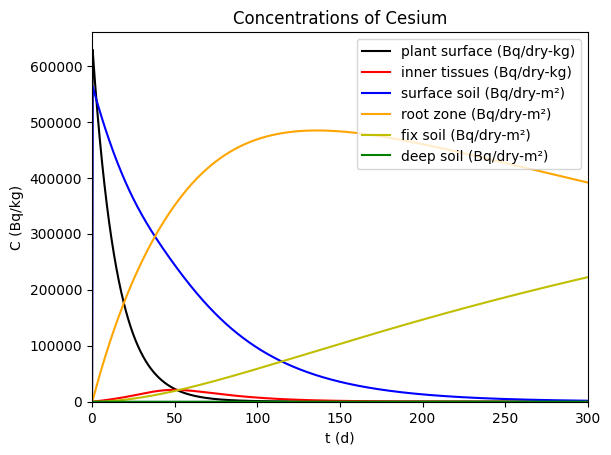

484558.287803883


In [117]:
#Plot
plt.plot(t, X1_cs, color='black', label = 'plant surface (Bq/dry-kg)')
plt.plot(t, X2_cs, color='r', label = 'inner tissues (Bq/dry-kg)')
plt.plot(t, X3_cs, color='blue', label = 'surface soil (Bq/dry-m²)')
plt.plot(t, X4_cs, color='orange', label = 'root zone (Bq/dry-m²)')
plt.plot(t, X5_cs, color='y', label = 'fix soil (Bq/dry-m²)')
plt.plot(t, X6_cs, color='g', label = 'deep soil (Bq/dry-m²)')
plt.title('Concentrations of Cesium')
plt.xlabel('t (d)')
plt.xlim(left=0, right=300)
plt.ylim(bottom = 0)
plt.ylabel('C (Bq/kg)')
plt.legend(loc = 'upper right')
plt.show()

print(max(X4_cs))

CONCENTRATIONS FOR IODINE

In [109]:
#Initial conditions
X1_i = np.zeros(n+1) #Concentration at the plant surface (Bq/dry-kg)
X2_i = np.zeros(n+1) #Concentration in inner tissues (Bq/dry-kg)
X3_i = np.zeros(n+1) #Concentration at the surface soil (Bq/dry-m²)
X4_i = np.zeros(n+1) #Concentration in the root zone (Bq/dry-m²)
X5_i = np.zeros(n+1) #Concentration in the fix soil (Bq/dry-m²)
X6_i = np.zeros(n+1) #Concentration in the deep soil (Bq/dry-m²)

X1_i[0] = 0 
X2_i[0] = 0
X3_i[0] = 0 
X4_i[0] = 0
X5_i[0] = 0
X6_i[0] = 0

#Euler method
for i in range(n):
    RF_pasture[i] = 10**(-6) * np.exp(-0.01*i*dt) + 10**(-9)
    kre[i] = vd_i * (a*RF_agri + b*RF_rice + c*RF_pasture[i])

    Bf[i] = B_max * B_0 / ((B_max - B_0)*np.exp(-k_g*i*dt)+ B_0)
    derivative_Bf[i]=(B_max*B_0)*1/((B_max-B_0)*np.exp(-k_g*i*dt)+B_0)**2**(B_max-B_0)*k_g*np.exp(-k_g*i*dt)
    kup[i]=derivative_Bf[i]*CR_i/(ro_r*L_r)
    f[i]=1-np.exp(-alpha*Bf[i])

    X1_i[i+1] = (-(kw + lambda_g + ktr_i + lambda_d)*X1_i[i] + kre[i]*f[i]/Bf[i]*X3_i[i] + (vd_i*f[i]/Bf[i])*C_air_i[i])*dt + X1_i[i] #Plant surface compartment
    X2_i[i+1] = (-(lambda_g + lambda_d)*X2_i[i] + kup[i]/Be*X4_i[i] + ktr_i*Bf[i]/Be*X1_i[i])*dt + X2_i[i] #Inner tissues
    X3_i[i+1] = (-(kpc + kre[i]*f[i] + lambda_d)*X3_i[i] + kw*Bf[i]*X1_i[i]+ vd_i*(1-f[i])*C_air_i[i])*dt + X3_i[i] #Surface soil
    X4_i[i+1] = (-(kl_i + kup[i] + lambda_d)*X4_i[i] + kpc*X3_i[i])*dt + X4_i[i] #Root zone
    X5_i[i+1] = (-(lambda_d)*X5_i[i])*dt + X5_i[i] #Fix soil
    X6_i[i+1] = (-(lambda_d)*X6_i[i] + kl_i*X4_i[i])*dt + X6_i[i] #Deep soil
    t[i+1] = t[i] + dt #Time

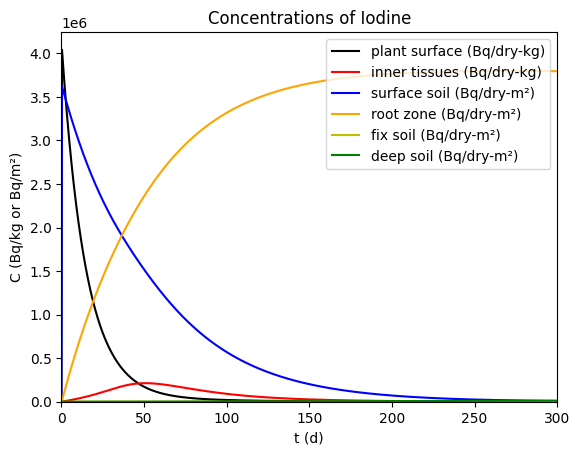

In [116]:
#Plot
plt.plot(t, X1_i, color='black', label = 'plant surface (Bq/dry-kg)')
plt.plot(t, X2_i, color='r', label = 'inner tissues (Bq/dry-kg)')
plt.plot(t, X3_i, color='blue', label = 'surface soil (Bq/dry-m²)')
plt.plot(t, X4_i, color='orange', label = 'root zone (Bq/dry-m²)')
plt.plot(t, X5_i, color='y', label = 'fix soil (Bq/dry-m²)')
plt.plot(t, X6_i, color='g', label = 'deep soil (Bq/dry-m²)')
plt.title('Concentrations of Iodine')
plt.xlabel('t (d)')
plt.xlim(left=0, right=300)
plt.ylim(bottom = 0)
plt.ylabel('C (Bq/kg or Bq/m²)')
plt.legend(loc = 'upper right')
plt.show()

